In [ ]:
"""
Random Forest Regression Pipeline for Outgoing Calls Prediction
================================================================

This script builds, tunes, and evaluates a Random Forest model to predict 
the total number of outgoing calls in month 9 for a telecommunication company's customers.

Main Steps:
-----------
1. Load and prepare the training dataset (`train_data_encoded.csv`).
2. Perform hyperparameter tuning using manual grid search with 5-Fold Cross-Validation,
   minimizing Mean Squared Error (MSE).
3. Retrieve best hyperparameters and retrain the model on the full training data.
4. Evaluate model performance using out-of-fold predictions to obtain an unbiased 
   estimate of generalization (cross-validated MSE and R² score).
5. Predict outgoing calls on the unlabeled test dataset (`test_data_encoded.csv`).
6. Save final predictions as a plain `.txt` file, one prediction per line, without headers,
   formatted according to submission requirements.

Key Features:
--------------
- Progress bars (`tqdm`) for monitoring training and cross-validation.
- Caching of grid search results to speed up repeated experiments.
- Handling of negative predictions by clipping to zero.
- Clean conversion between pandas DataFrames and NumPy arrays to avoid feature name warnings.

Files:
------
- Input: 
    - `train_data_encoded.csv` : Labeled training data
    - `test_data_encoded.csv`  : Unlabeled test data
- Output:
    - `predicted_RF.txt` : Final Random Forest predictions, ready for submission.

"""

In [ ]:
import pandas as pd

train_data_encoded = pd.read_csv('../data/train_encoded.csv')
test_data_encoded = pd.read_csv('../data/test_encoded.csv')
# train_data_encoded.info()

# since random forest is resistent to outliers, we just skip these steps

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# 1. Load & prepare data
X = train_data_encoded.drop('y', axis=1).values
y = train_data_encoded['y']

# 2. CV and parameter grid setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators':     [200, 500, 700],
    'min_samples_leaf': [1, 5, 10],
    'max_depth':        [None, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.3]
}
grid = list(ParameterGrid(param_grid))

# 3. Manual grid search with progress bar
results = []

for params in tqdm(grid, desc="Hyperparameter tuning"):
    # fold_mse = []
    fold_rmse = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        y_val_pred = rf.predict(X_val)
        
        mse = mean_squared_error(y_val, y_val_pred)
        rmse = np.sqrt(mse)
        # fold_mse.append(mse)
        fold_rmse.append(rmse)
    
    # avg_mse = np.mean(fold_mse)
    avg_rmse = np.mean(fold_rmse)
    results.append({**params, 'avg_mse': avg_rmse})
    # results.append({**params, 'avg_mse': avg_mse})

# 4. Summarize results
results_df = pd.DataFrame(results).sort_values('avg_rmse').reset_index(drop=True)
print("\nTop 5 hyperparameter settings by CV-estimated RMSE:")
print(results_df.head(5).to_string(index=False))

best_params = results_df.loc[0, list(param_grid.keys())].to_dict()

# --------- Fix NaNs and floats if needed ---------
best_params = {
    k: (None if pd.isna(v) else int(v) if k in ['n_estimators', 'min_samples_leaf', 'max_depth'] else v)
    for k, v in best_params.items()
}
# --------------------------------------------------
print(f"\nBest params: {best_params}")
print(f"Best CV-estimated RMSE: {results_df.loc[0,'avg_rmse']:.4f}")

C:\Users\Bohua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Hyperparameter tuning: 100%|██████████| 81/81 [41:14<00:00, 30.55s/it]  


Top 5 hyperparameter settings by CV-estimated MSE:
 max_depth max_features  min_samples_leaf  n_estimators     avg_mse
      10.0          0.3                 1           500 4561.585598
      10.0          0.3                 1           700 4568.730250
      20.0          0.3                 1           700 4579.038372
      20.0          0.3                 1           500 4579.482571
      10.0          0.3                 1           200 4591.444004

Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 10, 'max_features': 0.3}
Best CV-estimated MSE: 4561.5856


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import hashlib
import pickle

# 1. Load & prepare data
X = train_data_encoded.drop('y', axis=1).values
y = train_data_encoded['y']

# 2. CV and parameter grid setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators':     [200, 500, 700],
    'min_samples_leaf': [1, 5, 10],
    'max_depth':        [None, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.3]
}
grid = list(ParameterGrid(param_grid))

# 3. Create a cache dictionary
cache = {}

# Optional: Try loading existing cache from file
try:
    with open('rf_grid_cache.pkl', 'rb') as f:
        cache = pickle.load(f)
    print("Cache loaded from file.")
except FileNotFoundError:
    print("No cache file found, starting fresh.")

# 4. Manual grid search with caching
results = []

for params in tqdm(grid, desc="Hyperparameter tuning"):
    # Generate a unique key for the parameter combination
    params_str = str(sorted(params.items()))
    # print(params_str)
    params_hash = hashlib.md5(params_str.encode()).hexdigest()
    
    if params_hash in cache:
        avg_mse = cache[params_hash]
        print(f"Found cached result for {params} -> MSE: {avg_mse:.4f}")
    else:
        fold_mse = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
            rf.fit(X_tr, y_tr)
            y_val_pred = rf.predict(X_val)

            mse = mean_squared_error(y_val, y_val_pred)
            fold_mse.append(mse)

        avg_mse = np.mean(fold_mse)
        cache[params_hash] = avg_mse  # Save new result
        print(f"Computed and cached result for {params} -> MSE: {avg_mse:.4f}")

    results.append({**params, 'avg_mse': avg_mse})

# 5. Save updated cache
with open('rf_grid_cache.pkl', 'wb') as f:
    pickle.dump(cache, f)

# 6. Summarize results
results_df = pd.DataFrame(results).sort_values('avg_mse').reset_index(drop=True)
print("\nTop 5 hyperparameter settings by CV-estimated MSE:")
print(results_df.head(5).to_string(index=False))

best_params = results_df.loc[0, list(param_grid.keys())].to_dict()

# Fix NaNs and floats if needed
best_params = {
    k: (None if pd.isna(v) else int(v) if k in ['n_estimators', 'min_samples_leaf', 'max_depth'] else v)
    for k, v in best_params.items()
}

print(f"\nBest params: {best_params}")
print(f"Best CV-estimated MSE: {results_df.loc[0,'avg_mse']:.4f}")


Cross-Validation Folds: 100%|██████████| 5/5 [00:42<00:00,  8.41s/it]


5-Fold CV MSE: 4561.59
5-Fold CV R² Score: 0.7818


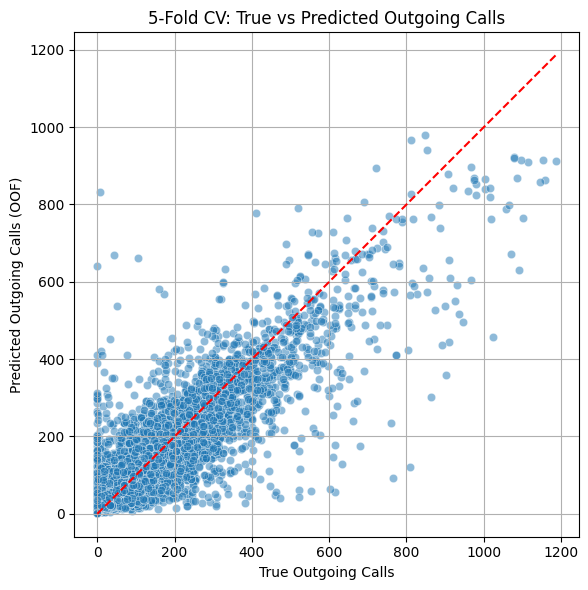

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Load & Prepare the Data
X = train_data_encoded.drop('y', axis=1).values
y = train_data_encoded['y'].values

# Set up 5-Fold CV and Random Forest Regressor
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Best params
# Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 10, 'max_features': 0.3}
# Best CV-estimated MSE: 4561.5856
best_n_estimators = 500
best_min_samples_leaf = 1
best_max_depth = 10
best_max_features = 0.3

# Create empty prediction array
y_oof_pred = np.zeros_like(y, dtype=float)

# Manual CV loop with progress bar
for fold_idx, (train_idx, val_idx) in enumerate(tqdm(cv.split(X, y), total=5, desc="Cross-Validation Folds")):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    rf = RandomForestRegressor(
        n_estimators=best_n_estimators,
        min_samples_leaf=best_min_samples_leaf,
        max_depth=best_max_depth,
        max_features=best_max_features,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_oof_pred[val_idx] = rf.predict(X_val)

# Evaluate OOF performance
mse = mean_squared_error(y, y_oof_pred)
r2 = r2_score(y, y_oof_pred)

print(f"5-Fold CV MSE: {mse:.2f}")
print(f"5-Fold CV R² Score: {r2:.4f}")

# Visualize true vs predicted (out-of-fold)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_oof_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Outgoing Calls")
plt.ylabel("Predicted Outgoing Calls (OOF)")
plt.title("5-Fold CV: True vs Predicted Outgoing Calls")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Retrain on Full Labeled Data
rf_full = RandomForestRegressor(
   n_estimators=best_n_estimators,
    min_samples_leaf=best_min_samples_leaf,
    max_depth=best_max_depth,
    max_features=best_max_features,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y)

# Predict on Unlabeled Test Data
X_test = test_data_encoded.copy()

y_test_pred = rf_full.predict(X_test.values)

# clip predictions (no negative call counts)
y_test_pred = np.clip(y_test_pred, 0, None)

# Save Final Predictions
# Save predictions as a plain TXT file (one prediction per line, no header)
np.savetxt('../prediction/predicted_RF.txt', y_test_pred, fmt='%.6f')
print("\nPredictions saved to '../prediction/predicted_RF.txt'.") # score 38.52



Predictions saved to '../prediction/predicted_RF.txt'.
